In [1]:
import warnings

import astropy.units
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import re
import scipy

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAv4Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

459


,survey_id_subid,survey_id,prism_filepath,prism_redshift,grating_filepaths,grating_redshifts,determined_redshift,file_count,available_filters,properties
0,snh0pe-v4_4446_102,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",0.2259,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
1,snh0pe-v4_4446_143,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.6318,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",1.6311,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
2,snh0pe-v4_4446_285,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.4446,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 0.4462, 'g235m-f170lp': 0.4462}",0.4462,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
3,snh0pe-v4_4446_29,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7834,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",1.77975,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
4,snh0pe-v4_4446_123,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",1.7855,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
...,...,...,...,...,...,...,...,...,...,...
32564,ceers-ddt-v4_2750_1636,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,3.0592,{},{},3.0592,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32565,ceers-ddt-v4_2750_3213,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,4.8013,{},{},4.8013,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32566,ceers-ddt-v4_2750_340,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,0.9585,{},{},0.9585,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32567,ceers-ddt-v4_2750_21413,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,2.1402,{},{},2.1402,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."


In [2]:
from importlib import resources
from pathlib import Path
from urllib import request

import matplotlib.pyplot as plt
import numpy as np

from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib

import astropy.units as u
import astropy.constants as const
from astropy.io import fits as asfits

In [9]:
srcypos=[]
ypixelpos=[]
SourcePos=[]
for id, catalog in tqdm(DJAv4Catalog.catalog_iterator(20000)):
    # if not catalog['properties']['Sample_Flag']:
    #     continue

    hdul = asfits.open(catalog['prism_filepath'])
    srcypos.append(hdul[3].header['SRCYPOS'])
    ypixelpos.append(hdul[7].data[0]['source_ypixel_position'])
    SourcePos.append(((hdul[3].header['SRCXPOS'])*0.2, (hdul[3].header['SRCYPOS'])*0.46))
    hdul.close()




459it [00:06, 73.44it/s]


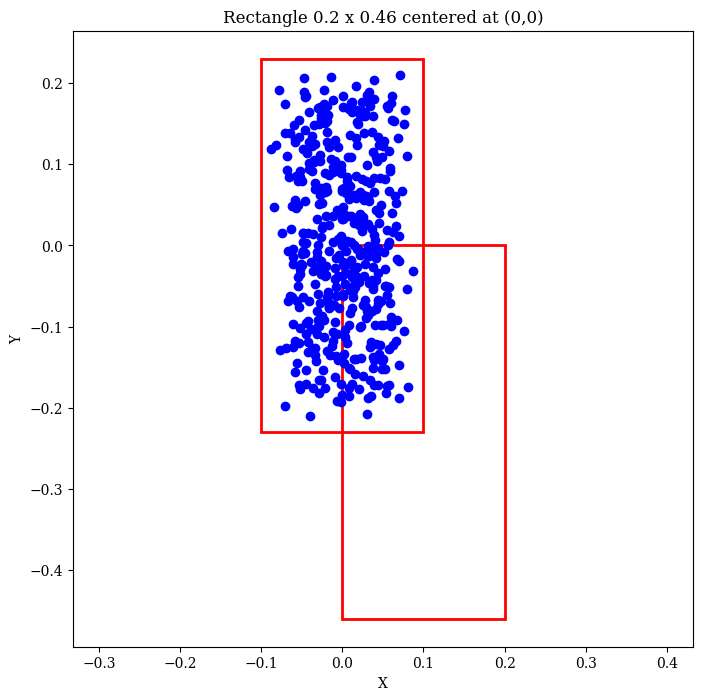

In [12]:
plt.figure(figsize=(8,8))
rect = plt.Rectangle((-0.1, -0.23), 0.2, 0.46, linewidth=2, edgecolor='r', facecolor='none')
rectac = plt.Rectangle((0, -0.46), 0.2, 0.46, linewidth=2, edgecolor='r', facecolor='none')
ax = plt.gca()
ax.add_patch(rect)
ax.add_patch(rectac)
plt.xlim(-0.3, 0.3)
plt.ylim(-0.5, 0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.title('Rectangle 0.2 x 0.46 centered at (0,0)')
for pos in SourcePos:
    plt.plot(pos[0], pos[1], 'bo')
plt.show()


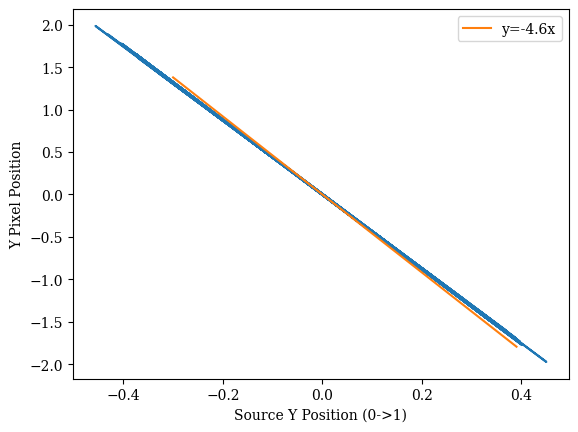

In [39]:
plt.plot(srcypos,ypixelpos)
plt.plot(np.arange(-0.3,0.4,0.01),np.arange(-0.3,0.4,0.01)*(-4.6),label='y=-4.6x')
plt.xlabel('Source Y Position (0->1)')
plt.ylabel('Y Pixel Position')
plt.legend()
plt.show()

In [40]:
hdul.info()

Filename: /home/xingyaocai/DJAv4/ceers-v4/ceers-v4_prism-clear_1345_4210.spec.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SPEC1D        1 BinTableHDU    366   473R x 9C   [D, D, D, D, D, D, D, D, D]   
  2  SCI           1 ImageHDU       343   (473, 31)   float64   
  3  WHT           1 ImageHDU       343   (473, 31)   float64   
  4  PROFILE       1 ImageHDU       343   (473, 31)   float64   
  5  PROF1D        1 BinTableHDU     25   31R x 3C   [D, D, D]   
  6  BACKGROUND    1 ImageHDU       343   (473, 31)   float64   
  7  SLITS         1 BinTableHDU    103   3R x 47C   ['64A', 'K', 'K', 'D', 'D', 'D', 'D', 'D', 'K', '9A', 'D', 'D', 'D', 'D', '3A', 'K', 'K', 'D', 'D', 'K', 'K', 'K', 'K', 'K', 'K', 'K', '4A', '5A', '5A', '25A', 'K', 'K', 'D', 'K', 'K', 'K', '7A', 'D', 'D', 'D', 'D', '17A', 'K', '4A', 'K', 'D', 'D']   


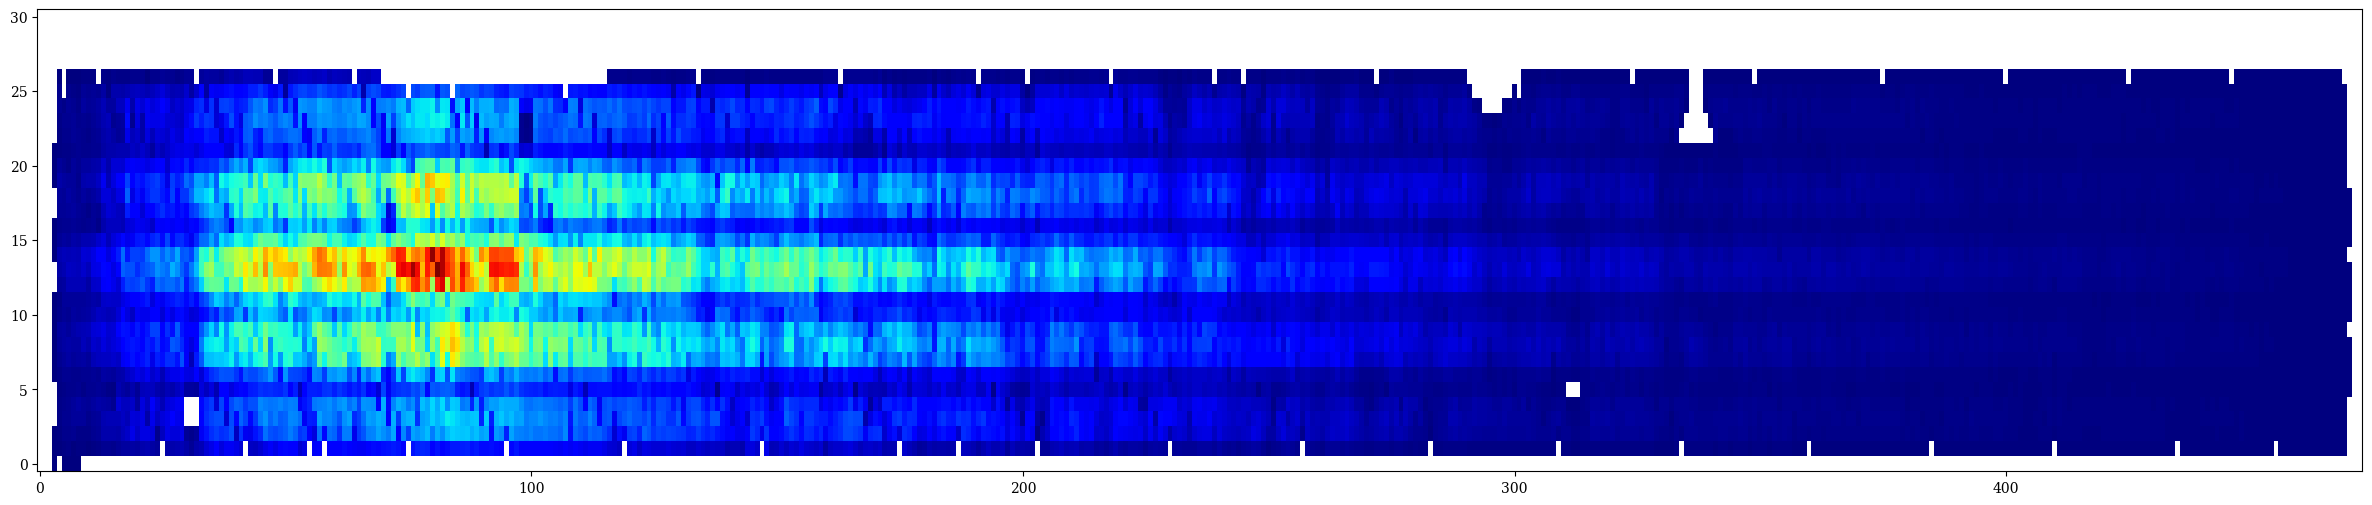

In [10]:
plt.figure(figsize=(30,6))
plt.imshow((hdul[3].data), origin='lower', aspect='auto', cmap='jet')


In [42]:
hdul[3].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  473                                                  
NAXIS2  =                   31                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
DATE    = '2025-01-22T13:21:49.784' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01345065001_03101_00001_nrs2_clear_prism_raw.89.1345_4210.fits' / N
SDP_VER = '2023_2a '        

In [9]:
hdul[7].data

FITS_rec([('jw01180025001_11101_00001_nrs1_clear_prism_raw.490.1180_15345.fits', 516, 24, 0.92766542, -0.84202403, 13.7719467 , 0.1035362, 1.37414993, 15345, '1180_15345', 53.1004368, -27.7712558, -0.16299999, -0.311, '1x1', 40838, 490, -2.2 , 2.2 , 4, 323, 112, 860, 516, 261, 24, 'NRS1', 'PRISM', 'CLEAR', 'jw01180025001_03_msa.fits', 3, 329, 1240.056, 5, 17, 1, 'NRSIRS2', 59859.67414649, -27.75244831, 308.08012389, 52.94349599, '3-SHUTTER-SLITLET', 1, 'NONE', 3, -140.29897657, 90.82524358),
          ('jw01180025001_11101_00002_nrs1_clear_prism_raw.490.1180_15345.fits', 516, 24, 0.92766542, -0.84202403, 18.88102332, 0.1035362, 1.37414993, 15345, '1180_15345', 53.1004368, -27.7712558, -0.17399999, -0.323, 'x11', 40473, 490, -1.05, 3.35, 4, 323, 111, 860, 516, 261, 24, 'NRS1', 'PRISM', 'CLEAR', 'jw01180025001_03_msa.fits', 3, 329, 1240.056, 5, 17, 1, 'NRSIRS2', 59859.68985017, -27.75245696, 308.08018598, 52.94333022, '3-SHUTTER-SLITLET', 2, 'NONE', 3, -140.29896839, 91.35421798),
      

In [7]:

for id, catalog in tqdm(DJAv4Catalog.catalog_iterator(10)):
    if not catalog['properties']['Sample_Flag']:
        continue

    print(catalog['prism_filepath'])
    hdul=asfits.open(catalog['prism_filepath'])
    print(hdul[3].header['targ_ra'],',', hdul[3].header['targ_dec'])

10it [00:00, 190.62it/s]

/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_prism-clear_4446_511.spec.fits
171.7964183333333 , 42.474825
/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_prism-clear_4446_19.spec.fits
171.7964183333333 , 42.474825
/home/xingyaocai/DJAv4/goodsn-wide2-v4/goodsn-wide2-v4_prism-clear_1211_3513.spec.fits
189.162885 , 62.14530833333333
/home/xingyaocai/DJAv4/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_3008.spec.fits
189.1338629166667 , 62.26666111111111
/home/xingyaocai/DJAv4/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_2347.spec.fits
189.1338629166667 , 62.26666111111111
/home/xingyaocai/DJAv4/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1580.spec.fits
189.1338629166667 , 62.26666111111111
/home/xingyaocai/DJAv4/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_721.spec.fits
189.1338629166667 , 62.26666111111111
/home/xingyaocai/DJAv4/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_940.spec.fits
189.1338629166667 , 62.26666111111111
/home/xingyaocai/DJAv4/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1617